In [1]:
import sys
import os
import glob
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ------------------------------------------------------------
# 路径设置
# ------------------------------------------------------------
VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
FIXED_ROOT = os.path.join(VAE_ROOT, "fixed_size_20000")
MODEL_DIR = os.path.join(FIXED_ROOT, "model_saved_more")
OUT_DIR = os.path.join(FIXED_ROOT, "verifier_top10_results_all_models")
os.makedirs(OUT_DIR, exist_ok=True)

sys.path.append(VAE_ROOT)
import models as models
import train_helper as train_helper
import data_helper as data_helper

# ------------------------------------------------------------
# 设备 & 随机种子
# ------------------------------------------------------------
base_seed = 0
torch.manual_seed(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(base_seed)

print("Device:", device)
print("MODEL_DIR:", MODEL_DIR)
print("OUT_DIR:", OUT_DIR)

# 生成 & 选择设置
TOTAL_SAMPLES = 200_000   # 200k synthetic，理论上20k每类
TOP_FRAC = 0.10           # top 10%


Device: cuda
MODEL_DIR: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/model_saved_more
OUT_DIR: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/verifier_top10_results_all_models


In [2]:
# ------------------------------------------------------------
# 你的 SyntheticDiscriminator 定义
# ------------------------------------------------------------
class SyntheticDiscriminator(nn.Module):
    """
    A flexible discriminator that can be trained with the same training function as CVAE.
    Works with flattened images (784 dimensions) like CVAE.
    """

    def __init__(self, input_dim=784):
        super().__init__()
        self.label_dim = 2  # Binary classification: 0 (fake) or 1 (real)
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)  # Keep [batch_size, 1] shape for logits

    def score(self, x):
        """
        Score images to get discriminator predictions.

        Args:
            x: Input images [batch_size, 784] (flattened) or [batch_size, 1, 28, 28]

        Returns:
            Scores [batch_size, 1] where higher values indicate more real-like images
        """
        # Ensure input is flattened
        if x.dim() == 4 and x.shape[1] == 1:
            # Input is [batch_size, 1, 28, 28], flatten to [batch_size, 784]
            x = x.view(x.size(0), -1)
        elif x.dim() != 2 or x.shape[1] != 784:
            raise ValueError(
                f"Expected input shape [batch_size, 784] or [batch_size, 1, 28, 28], got {x.shape}"
            )

        # Forward pass and apply sigmoid
        logits = self.forward(x)  # [batch_size, 1]
        scores = torch.sigmoid(logits)  # [batch_size, 1]
        return scores

    def loss(self, x, y):
        """
        Compute discriminator loss.

        Args:
            x: Input images [batch_size, 784] (flattened like CVAE)
            y: Labels [batch_size, 2] (one-hot: [1,0] for fake, [0,1] for real)
               OR [batch_size] (binary: 0 for fake, 1 for real)

        Returns:
            (total_loss, summary_dict)
        """
        x = (x > 0.5).float()
        logits = self.forward(x)  # [batch_size, 1]

        if y.dim() == 2 and y.size(1) == 2:
            y_binary = y[:, 1]  # second col: real=1
        else:
            y_binary = y.view(-1).float()
        y_binary = y_binary.view(-1, 1)

        total_loss = F.binary_cross_entropy_with_logits(
            logits, y_binary, reduction='sum'
        )

        predictions = (logits > 0).float()
        correct = (predictions.squeeze(-1) == y_binary.squeeze(-1)).sum()
        summary = {'accuracy': correct.item()}
        return total_loss, summary


# ------------------------------------------------------------
# 生成 synthetic 的函数（和你之前的一致）
# ------------------------------------------------------------
@torch.no_grad()
def generate_images_in_batches(
    model,
    total_samples,
    latent_dim=20,
    num_classes=10,
    batch_size=10_000,
    device="cuda",
):
    """
    返回:
        images: [N, 1, 28, 28] in [0,1] (CPU)
        labels: [N] (CPU)
    """
    model.eval()
    generated_images = []
    all_labels = []

    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        z = torch.randn(n, latent_dim, device=device)
        y = labels_full[start:end].to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()

        logits_flat = model.decoder.decode(z, y_onehot)  # (n, 784)
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y.cpu())

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels


# ------------------------------------------------------------
# 计算某个 verifier 对每个 digit top10% p 的函数
# ------------------------------------------------------------
@torch.no_grad()
def get_top_scores_per_digit(
    verifier,
    images,
    labels,
    top_frac=0.1,
    batch_size=4096,
    device="cuda",
):
    """
    Args:
        verifier: SyntheticDiscriminator
        images:   [N, 1, 28, 28] in [0,1] (CPU)
        labels:   [N] (CPU)
    Returns:
        dict: digit -> tensor of top scores (on CPU)
    """
    verifier.eval()
    N = images.size(0)

    all_scores = []
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        batch = images[start:end].to(device)
        scores = verifier.score(batch).squeeze(1)  # [B]
        all_scores.append(scores.cpu())
    scores = torch.cat(all_scores, dim=0)  # [N]

    top_scores_per_digit = {}
    for d in range(10):
        idx = (labels == d)
        digit_scores = scores[idx]
        num = digit_scores.numel()
        if num == 0:
            top_scores_per_digit[d] = torch.empty(0)
            continue
        k = max(1, int(num * top_frac))
        top_scores, _ = torch.topk(digit_scores, k)
        top_scores_per_digit[d] = top_scores
    return top_scores_per_digit


In [3]:
# ------------------------------------------------------------
# 加载 MNIST 真实数据（full train）
# ------------------------------------------------------------
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
print("Full MNIST train size:", len(full_dataset))


Full MNIST train size: 60000


In [4]:
# ------------------------------------------------------------
# 找到所有 CVAE 模型
# 这里简单用前缀 "cvae_conv" 过滤；如果你有别的命名可以改一下
# ------------------------------------------------------------
all_ckpts = sorted(glob.glob(os.path.join(MODEL_DIR, "*.pth")))
cvae_ckpts = [p for p in all_ckpts if os.path.basename(p).startswith("cvae_conv")]

print(f"Found {len(cvae_ckpts)} cvae_conv*.pth models:")
for p in cvae_ckpts:
    print("  -", os.path.basename(p))

# ------------------------------------------------------------
# 对每个 CVAE model：
#   1. load CVAE
#   2. 准备 discriminator dataset + 训练一个新的 SyntheticDiscriminator
#   3. 生成 200k synthetic
#   4. 对该 verifier 计算每个 digit 的 top10% p
#   5. 记录 summary 以及保存所有 p 值
# ------------------------------------------------------------
summary_rows = []
# 存所有 p 值: dict[model_name][digit] -> np.array
all_pvals = {}

for ckpt_path in cvae_ckpts:
    model_name = os.path.splitext(os.path.basename(ckpt_path))[0]
    print("\n========================================")
    print(f"[MODEL] {model_name}")
    print("Checkpoint:", ckpt_path)

    # ------------ 1. 加载 CVAE ------------
    cvae = models.CVAE(
        input_dim=784,
        label_dim=10,
        latent_dim=20,
        arch="conv",
    ).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    cvae.load_state_dict(state_dict)
    cvae.eval()
    print("[INFO] CVAE loaded.")

    # ------------ 2. 准备 discriminator dataset & 训练 verifier ------------
    print("[INFO] Preparing discriminator dataset...")
    disc_dataset = data_helper.prepare_discriminator_dataset(full_dataset, cvae, device)
    disc_loader = DataLoader(disc_dataset, batch_size=128, shuffle=True)
    print("[INFO] Discriminator dataset size:", len(disc_dataset))

    disc_model = SyntheticDiscriminator(input_dim=784).to(device)
    print("[INFO] Training SyntheticDiscriminator for this CVAE...")
    train_helper.train_model(
        model=disc_model,
        train_loader=disc_loader,
        device=device,
        epochs=80,
        lr=1e-3,
        patience=5,
        verbose=False,   # 你想看详细输出可以改成 True
    )
    print("[INFO] Discriminator training done.")

    # 释放一点内存
    del disc_loader, disc_dataset
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ------------ 3. 生成 200k synthetic ------------
    print(f"[INFO] Generating {TOTAL_SAMPLES} synthetic samples...")
    images_syn, labels_syn = generate_images_in_batches(
        cvae,
        total_samples=TOTAL_SAMPLES,
        latent_dim=20,
        num_classes=10,
        batch_size=10_000,
        device=device,
    )
    print("Synthetic images:", images_syn.shape, "labels:", labels_syn.shape)

    # ------------ 4. 计算 top10% p per digit ------------
    print("[INFO] Computing top 10% scores per digit...")
    top_scores_per_digit = get_top_scores_per_digit(
        disc_model,
        images_syn,
        labels_syn,
        top_frac=TOP_FRAC,
        batch_size=4096,
        device=device,
    )

    # 保存这个 model 的所有 p 值
    all_pvals[model_name] = {}

    for d in range(10):
        scores = top_scores_per_digit[d]
        if scores.numel() == 0:
            mean_p = float("nan")
            median_p = float("nan")
            min_p = float("nan")
            max_p = float("nan")
            k = 0
            arr = np.array([], dtype=np.float32)
        else:
            mean_p = scores.mean().item()
            median_p = scores.median().item()
            min_p = scores.min().item()
            max_p = scores.max().item()
            k = scores.numel()
            arr = scores.numpy()

        summary_rows.append(
            {
                "model_name": model_name,
                "digit": d,
                "top_fraction": TOP_FRAC,
                "top_k": k,
                "mean_p": mean_p,
                "median_p": median_p,
                "min_p": min_p,
                "max_p": max_p,
            }
        )
        all_pvals[model_name][f"digit_{d}"] = arr

    # 释放内存（下一个 model）
    del cvae, disc_model, images_syn, labels_syn, top_scores_per_digit
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n[INFO] Loop over all models finished.")


Found 41 cvae_conv*.pth models:
  - cvae_conv_init500_q0.1_s20000_r1.pth
  - cvae_conv_init500_q0.1_s20000_r10.pth
  - cvae_conv_init500_q0.1_s20000_r11.pth
  - cvae_conv_init500_q0.1_s20000_r12.pth
  - cvae_conv_init500_q0.1_s20000_r13.pth
  - cvae_conv_init500_q0.1_s20000_r14.pth
  - cvae_conv_init500_q0.1_s20000_r15.pth
  - cvae_conv_init500_q0.1_s20000_r16.pth
  - cvae_conv_init500_q0.1_s20000_r17.pth
  - cvae_conv_init500_q0.1_s20000_r18.pth
  - cvae_conv_init500_q0.1_s20000_r19.pth
  - cvae_conv_init500_q0.1_s20000_r2.pth
  - cvae_conv_init500_q0.1_s20000_r20.pth
  - cvae_conv_init500_q0.1_s20000_r21.pth
  - cvae_conv_init500_q0.1_s20000_r22.pth
  - cvae_conv_init500_q0.1_s20000_r23.pth
  - cvae_conv_init500_q0.1_s20000_r24.pth
  - cvae_conv_init500_q0.1_s20000_r25.pth
  - cvae_conv_init500_q0.1_s20000_r26.pth
  - cvae_conv_init500_q0.1_s20000_r27.pth
  - cvae_conv_init500_q0.1_s20000_r28.pth
  - cvae_conv_init500_q0.1_s20000_r29.pth
  - cvae_conv_init500_q0.1_s20000_r3.pth
  - c

/tmp/ipykernel_1448431/2577452011.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location=device)


[INFO] Discriminator dataset size: 120000
[INFO] Training SyntheticDiscriminator for this CVAE...
[INFO] Discriminator training done.
[INFO] Generating 200000 synthetic samples...
Synthetic images: torch.Size([200000, 1, 28, 28]) labels: torch.Size([200000])
[INFO] Computing top 10% scores per digit...

[MODEL] cvae_conv_init500_q0.1_s20000_r10
Checkpoint: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_20000/model_saved_more/cvae_conv_init500_q0.1_s20000_r10.pth
[INFO] CVAE loaded.
[INFO] Preparing discriminator dataset...
[INFO] Discriminator dataset size: 120000
[INFO] Training SyntheticDiscriminator for this CVAE...
[INFO] Discriminator training done.
[INFO] Generating 200000 synthetic samples...
Synthetic images: torch.Size([200000, 1, 28, 28]) labels: torch.Size([200000])
[INFO] Computing top 10% scores per digit...

[MODEL] cvae_conv_init500_q0.1_s20000_r11
Checkpoint: /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_2

KeyboardInterrupt: 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ====== 1. 确保 all_pvals 存在 ======
# 如果你刚刚跑完前面的循环，all_pvals 应该已经在 globals 里了
# 如果没有，就从 npz 里读回来
if 'all_pvals' not in globals():
    # 改成你实际保存 npz 的路径
    VAE_ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
    FIXED_ROOT = os.path.join(VAE_ROOT, "fixed_size_20000")
    OUT_DIR = os.path.join(FIXED_ROOT, "verifier_top10_results_all_models")
    npz_path = os.path.join(OUT_DIR, "verifier_top10_pvalues_all_models.npz")

    print(f"[INFO] Reloading all_pvals from {npz_path}")
    loaded = np.load(npz_path)

    all_pvals = {}
    for key, arr in loaded.items():
        # key 形如 "cvae_conv_init500_q0.1_s20000_r1__digit_0"
        model_name, digit_key = key.split("__")
        all_pvals.setdefault(model_name, {})[digit_key] = arr

# ====== 2. 计算每个 digit 在每个 model 下的 threshold ======
digit_thresholds = {d: [] for d in range(10)}

for model_name, digit_dict in all_pvals.items():
    for d in range(10):
        arr = digit_dict.get(f"digit_{d}", None)
        if arr is None or arr.size == 0:
            continue
        # threshold 定义为 top10% p 值里的最小值
        thr = float(arr.min())
        digit_thresholds[d].append(thr)

# 打个 summary 看看每个 digit 的数量
for d in range(10):
    print(f"Digit {d}: {len(digit_thresholds[d])} thresholds")


Digit 0: 7 thresholds
Digit 1: 7 thresholds
Digit 2: 7 thresholds
Digit 3: 7 thresholds
Digit 4: 7 thresholds
Digit 5: 7 thresholds
Digit 6: 7 thresholds
Digit 7: 7 thresholds
Digit 8: 7 thresholds
Digit 9: 7 thresholds


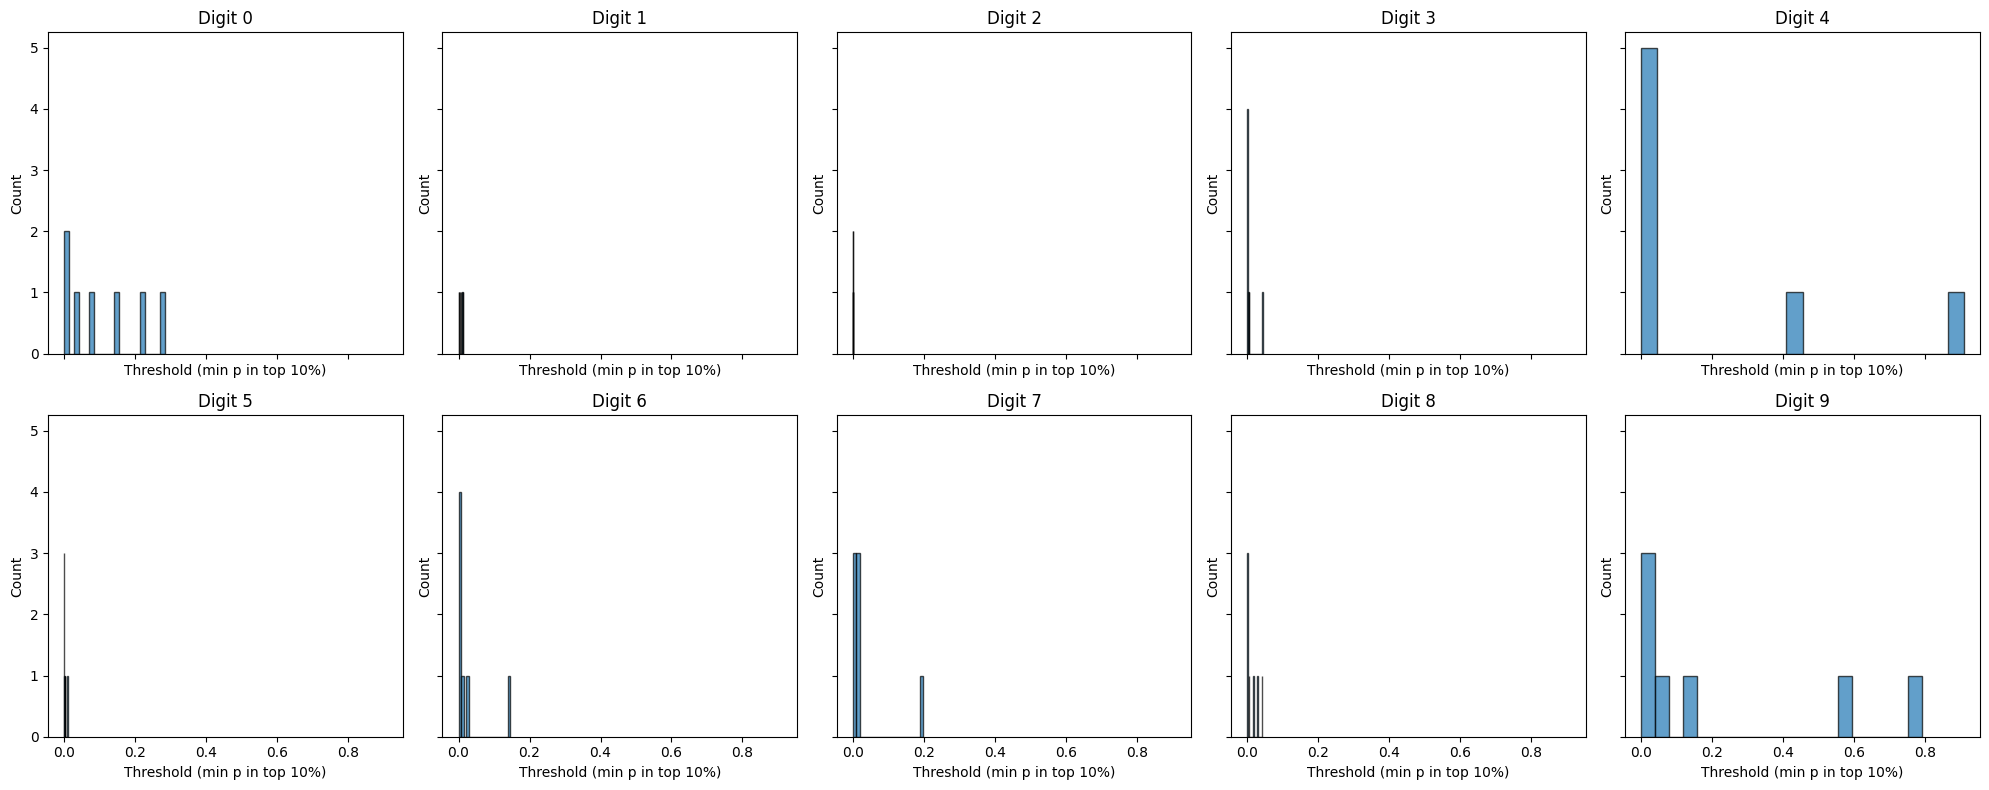

In [6]:
# 画每个 digit 在所有 model 中的 threshold histogram

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.ravel()

for d in range(10):
    ax = axes[d]
    vals = digit_thresholds[d]

    if len(vals) == 0:
        ax.set_title(f"Digit {d}")
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    ax.hist(vals, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"Digit {d}")
    ax.set_xlabel("Threshold (min p in top 10%)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:
print("==== Threshold (min p in top 10%) for each model ====\n")

for d in range(10):
    thrs = digit_thresholds[d]
    print(f"Digit {d}:")
    print(thrs)
    print("-" * 40)
0

==== Threshold (min p in top 10%) for each model ====

Digit 0:
[7.25416794011835e-06, 0.07122398912906647, 0.28280743956565857, 0.0010237673996016383, 0.03657619655132294, 0.14369633793830872, 0.22605836391448975]
----------------------------------------
Digit 1:
[5.677716217178386e-07, 0.011164098978042603, 0.004354727920144796, 0.002114461502060294, 0.009080518037080765, 0.01257447712123394, 0.007010746281594038]
----------------------------------------
Digit 2:
[2.6606511482896167e-07, 9.050001244759187e-05, 0.00024049196508713067, 8.518526010448113e-05, 0.00036647371598519385, 4.270448334864341e-05, 0.0013615554198622704]
----------------------------------------
Digit 3:
[1.0463289754625293e-06, 0.04503537714481354, 0.003501900704577565, 0.00027644055080600083, 0.0011046265717595816, 0.005371482111513615, 0.0017232439713552594]
----------------------------------------
Digit 4:
[3.8602527752118476e-07, 0.908877432346344, 0.001792052760720253, 0.00011029982852051035, 0.0121712824329